# Getting started: one-step MLP predictor for the logistic ODE

This notebook is a minimal starting point for the "MLP" task on Worksheet 8. It mirrors the
Neural-ODE starter, but uses a **feed-forward one-step predictor** instead of integrating a
neural vector field.

Idea: given a point $x(t_k)$, train a network to predict the next point $x(t_{k+1})$. The
network is **Markovian** (it only sees the current state), so to obtain a whole trajectory we
**roll it out autoregressively**: feed each prediction back in as the next input.

We demonstrate this on the logistic ODE $\dot{x}=r\,x(1-x/K)$ with $r=2$, $K=1$ (the same toy
system as the Neural-ODE starter). For the lab you extend this exact recipe to the 3-D Lorenz
system.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# The training data come from scipy, and the network is a plain MLP (no torchdiffeq), so the
# MPS backend works fine here.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
np.random.seed(7)
torch.manual_seed(7)
print("Using device:", device)

Using device: mps


## 1. Generate training data

We integrate many logistic trajectories from random initial conditions and turn them into
one-step input/target pairs $\big(x(t_k),\,x(t_{k+1})\big)$. As suggested on the worksheet, we
normalise the data to $[-1, 1]$ before feeding it to the network.

In [2]:
r, K = 2.0, 1.0
N_TRAJ = 64
N_TIME = 161
T = 4.0

def logistic_rhs(t, x, r=r, K=K):
    return r * x * (1.0 - x / K)

t = np.linspace(0.0, T, N_TIME)

# random initial conditions in (0, 1)
x0 = np.random.uniform(0.02, 0.98, size=N_TRAJ)

# integrate every trajectory with scipy
traj = np.stack([
    solve_ivp(logistic_rhs, (t[0], t[-1]), [x0i], t_eval=t).y[0]
    for x0i in x0
])  # shape [N_TRAJ, N_TIME]

# Split at the *trajectory* level (not on the flattened one-step pairs): this keeps whole
# held-out trajectories intact so we can roll the network out on them later.
traj_train, traj_test = train_test_split(traj, test_size=0.2, random_state=7)

# normalise to [-1, 1] using the *training* data range only (no leakage from the test set);
# keep the mapping so we can invert it later
x_min, x_max = traj_train.min(), traj_train.max()
def normalize(a):
    return 2.0 * (a - x_min) / (x_max - x_min) - 1.0
def denormalize(a):
    return (a + 1.0) * 0.5 * (x_max - x_min) + x_min

# build the one-step (input, target) pairs x(t_k) -> x(t_{k+1}) *within* each set
def make_pairs(trajs):
    X = trajs[:, :-1].reshape(-1, 1)
    Y = trajs[:, 1:].reshape(-1, 1)
    return normalize(X), normalize(Y)

X_train, y_train = make_pairs(traj_train)
X_test,  y_test  = make_pairs(traj_test)

print("train trajectories:", traj_train.shape[0], "-> one-step pairs:", X_train.shape[0])
print("test  trajectories:", traj_test.shape[0],  "-> one-step pairs:", X_test.shape[0])
print("data range (train):", (float(x_min), float(x_max)))

train trajectories: 51 -> one-step pairs: 8160
test  trajectories: 13 -> one-step pairs: 2080
data range (train): (0.021369805340247867, 0.9999616738907287)


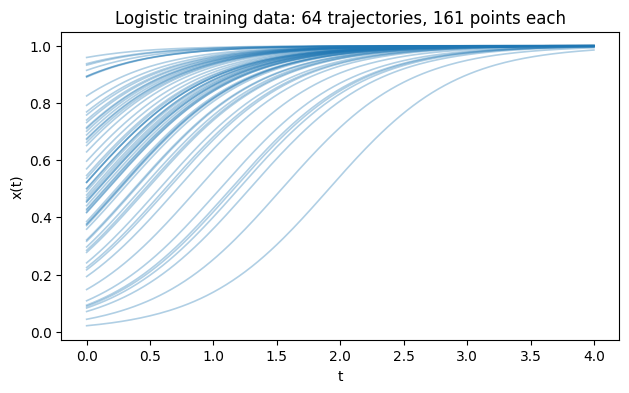

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for j in range(N_TRAJ):
    ax.plot(t, traj[j], color="C0", alpha=0.35, lw=1.2)
ax.set_xlabel("t")
ax.set_ylabel("x(t)")
ax.set_title(f"Logistic training data: {N_TRAJ} trajectories, {N_TIME} points each")
plt.show()

## 2. The one-step predictor

A small feed-forward network maps the current state to the next state. There is **no
activation after the output layer** (we are doing regression, not classification). The
architecture mirrors the one used for the Lorenz system in the lecture, but with a 1-D
input/output here.

In [4]:
class History:
    def __init__(self):
        self.history = {"loss": [], "val_loss": []}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FeedForwardNN(nn.Module):
    """One-step predictor: maps x(t_k) -> x(t_{k+1})."""
    def __init__(self, dim=1, hidden=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),   # no activation after the output
        )

    def forward(self, x):
        return self.net(x)


model = FeedForwardNN(dim=1, hidden=20).to(device)
print(model)
print(f"Trainable params: {count_parameters(model):,}")

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

FeedForwardNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)
Trainable params: 481


## 3. Train

Standard supervised regression on the one-step pairs, with an Adam optimizer and the mean
squared error. The `train_model` helper also tracks the validation loss.

In [5]:
def make_loader(X, y, batch_size=256, shuffle=True):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, optimizer, loss_fn, epochs, val_loader=None):
    hist = History()
    for epoch in range(epochs):
        model.train()
        train_loss, train_count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
            train_count += xb.shape[0]
        train_loss /= train_count
        hist.history["loss"].append(train_loss)
        message = f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.6g}"

        if val_loader is not None:
            model.eval()
            val_loss, val_count = 0.0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += loss_fn(model(xb), yb).item() * xb.shape[0]
                    val_count += xb.shape[0]
            val_loss /= val_count
            hist.history["val_loss"].append(val_loss)
            message += f" - val_loss: {val_loss:.6g}"

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(message)
    return hist


train_loader = make_loader(X_train, y_train, batch_size=256, shuffle=True)
val_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)
hist = train_model(model, train_loader, optimizer, loss_fn, epochs=200, val_loader=val_loader)

Epoch 1/200 - loss: 0.349303 - val_loss: 0.208285
Epoch 10/200 - loss: 0.000307374 - val_loss: 0.000178141
Epoch 20/200 - loss: 0.000233835 - val_loss: 0.000141411
Epoch 30/200 - loss: 0.000162136 - val_loss: 0.000100323
Epoch 40/200 - loss: 0.000105163 - val_loss: 6.90451e-05
Epoch 50/200 - loss: 7.84048e-05 - val_loss: 4.95798e-05
Epoch 60/200 - loss: 6.60481e-05 - val_loss: 3.89783e-05
Epoch 70/200 - loss: 5.54118e-05 - val_loss: 3.26647e-05
Epoch 80/200 - loss: 4.62451e-05 - val_loss: 2.77863e-05
Epoch 90/200 - loss: 3.71612e-05 - val_loss: 2.30485e-05
Epoch 100/200 - loss: 2.93814e-05 - val_loss: 1.80767e-05
Epoch 110/200 - loss: 2.26498e-05 - val_loss: 1.28955e-05
Epoch 120/200 - loss: 1.67018e-05 - val_loss: 1.00835e-05
Epoch 130/200 - loss: 1.19897e-05 - val_loss: 7.15842e-06
Epoch 140/200 - loss: 8.5254e-06 - val_loss: 5.22768e-06
Epoch 150/200 - loss: 5.46538e-06 - val_loss: 2.86668e-06
Epoch 160/200 - loss: 3.44913e-06 - val_loss: 1.94265e-06
Epoch 170/200 - loss: 1.90411e-0

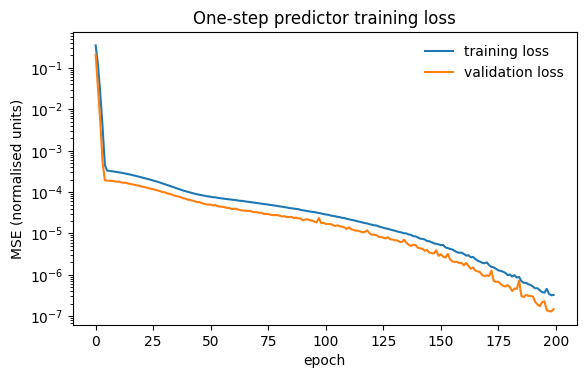

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist.history["loss"], label="training loss")
ax.semilogy(hist.history["val_loss"], label="validation loss")
ax.legend(frameon=False)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (normalised units)")
ax.set_title("One-step predictor training loss")
plt.show()

## 4. Autoregressive rollout

The trained network only predicts a single step. To reconstruct a whole trajectory we start
from $x_0$ and repeatedly feed the prediction back in. We compare the rollout against the true
solution for a few initial conditions taken from the held-out **test** trajectories.

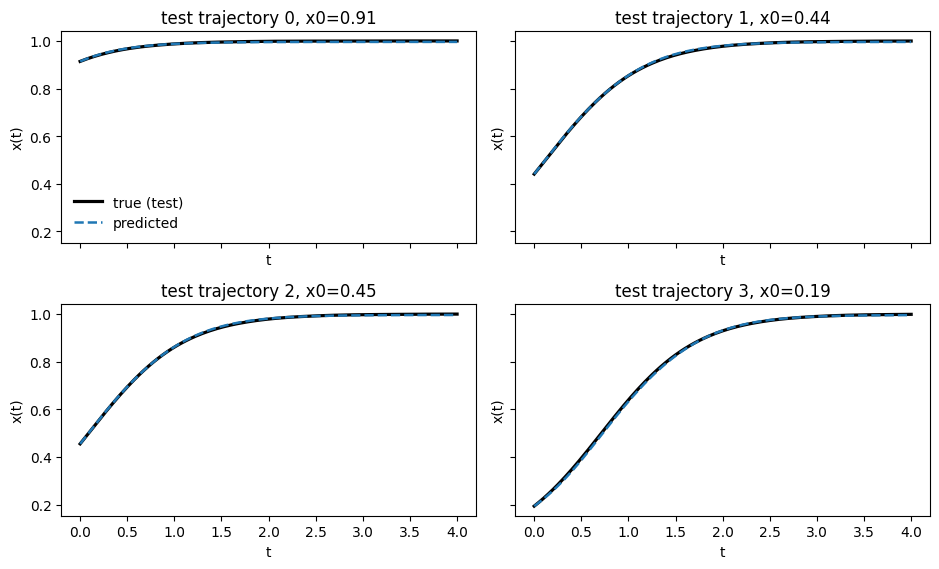

In [7]:
def rollout(model, x0, n_steps):
    """Iterate the one-step predictor n_steps times, starting from x0 (in physical units)."""
    model.eval()
    xs = np.zeros(n_steps + 1)
    xs[0] = x0
    with torch.no_grad():
        for k in range(n_steps):
            xn = normalize(np.array([[xs[k]]]))
            xn_next = model(torch.as_tensor(xn, dtype=torch.float32, device=device)).cpu().numpy()
            xs[k + 1] = denormalize(xn_next)[0, 0]
    return xs


# evaluate on the held-out test trajectories: start the rollout from each test trajectory's
# initial point and compare against the stored true trajectory (no re-integration needed)
n_show = min(4, traj_test.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.8), sharex=True, sharey=True)
for ax, j in zip(axes.ravel(), range(n_show)):
    true_i = traj_test[j]
    pred_i = rollout(model, true_i[0], N_TIME - 1)
    ax.plot(t, true_i, color="k", lw=2.3, label="true (test)")
    ax.plot(t, pred_i, color="C0", lw=1.8, ls="--", label="predicted")
    ax.set_title(f"test trajectory {j}, x0={true_i[0]:.2f}")
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")
axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()